shape: (4024, 6048)
dtype: uint16
black level: [512, 512, 512, 512]
white level: 16383
bayer pattern:
[[0 1]
 [3 2]]


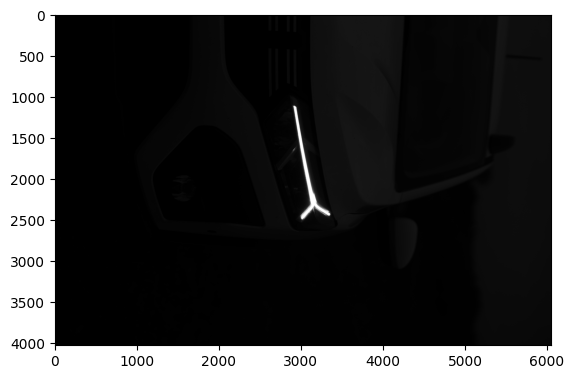

In [4]:
import rawpy
import numpy as np
import matplotlib.pyplot as plt

path = "images/DSC05370.ARW"

with rawpy.imread(path) as raw:

    sensor = raw.raw_image

    print("shape:", sensor.shape)
    print("dtype:", sensor.dtype)

    print("black level:", raw.black_level_per_channel)
    print("white level:", raw.white_level)

    print("bayer pattern:")
    print(raw.raw_pattern)

    raw_image = raw.raw_image.astype(np.float32)

    black = raw.black_level_per_channel[0]
    white = raw.white_level

    # rimuovi black level
    raw_image = raw_image - black

    # normalizza
    raw_image = raw_image / (white - black)

    raw_image = np.clip(raw_image, 0, 1)

    rgb = raw.postprocess()

plt.imshow(raw_image, cmap="gray")
plt.show()

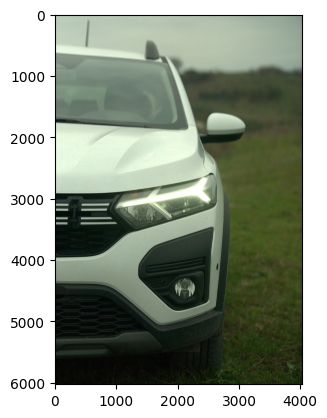

In [5]:
plt.imshow(rgb)
plt.show()

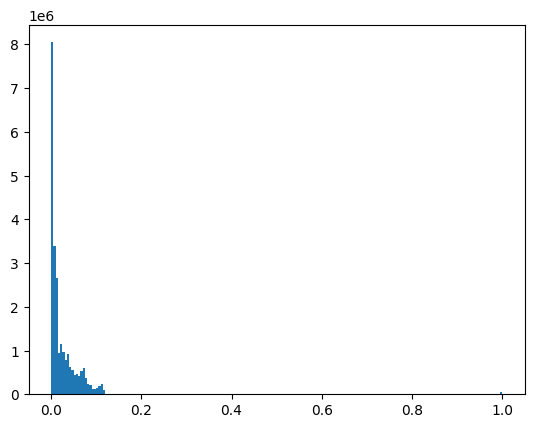

In [7]:
plt.hist(raw_image.flatten(), bins=200)
plt.show()

In [8]:
raw = rawpy.imread(path)

In [9]:
print("camera:", raw.camera_whitebalance)
print("black level:", raw.black_level_per_channel)
print("white level:", raw.white_level)
print("raw shape:", raw.raw_image.shape)
print("bayer pattern:")
print(raw.raw_pattern)

camera: [2912.0, 1024.0, 1736.0, 1024.0]
black level: [512, 512, 512, 512]
white level: 16383
raw shape: (4024, 6048)
bayer pattern:
[[0 1]
 [3 2]]


In [10]:
sensor = raw.raw_image

In [12]:
sensor[0:10, 0:10]

array([[508, 524, 516, 532, 520, 524, 516, 524, 504, 524],
       [536, 516, 524, 520, 532, 520, 524, 520, 520, 516],
       [520, 524, 520, 540, 508, 520, 508, 512, 508, 520],
       [520, 516, 536, 520, 512, 516, 512, 516, 532, 516],
       [520, 532, 516, 528, 508, 520, 520, 524, 516, 520],
       [532, 516, 524, 524, 532, 524, 524, 516, 524, 516],
       [516, 512, 520, 532, 516, 524, 516, 524, 516, 520],
       [520, 504, 520, 516, 520, 516, 520, 520, 520, 524],
       [520, 512, 516, 520, 516, 520, 508, 532, 516, 520],
       [520, 520, 524, 532, 524, 524, 524, 520, 508, 520]], dtype=uint16)

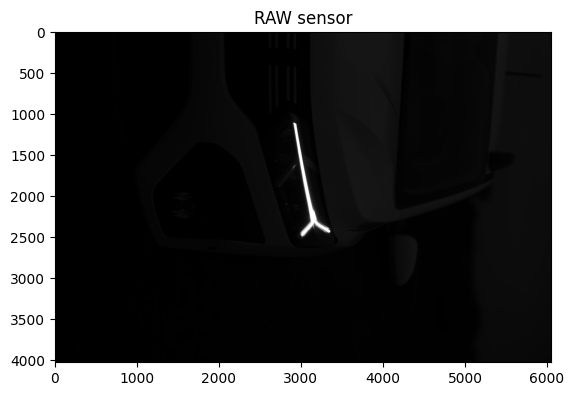

In [14]:
sensor = raw.raw_image.astype(np.float32)
black = raw.black_level_per_channel[0]
white = raw.white_level

sensor = (sensor - black) / (white - black)
sensor = np.clip(sensor, 0, 1)

plt.imshow(sensor, cmap="gray")
plt.title("RAW sensor")
plt.show()

In [15]:
r = sensor[0::2, 0::2]
g1 = sensor[0::2, 1::2]
g2 = sensor[1::2, 0::2]
b = sensor[1::2, 1::2]

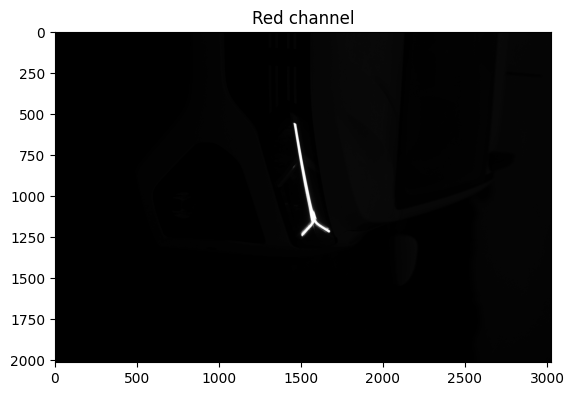

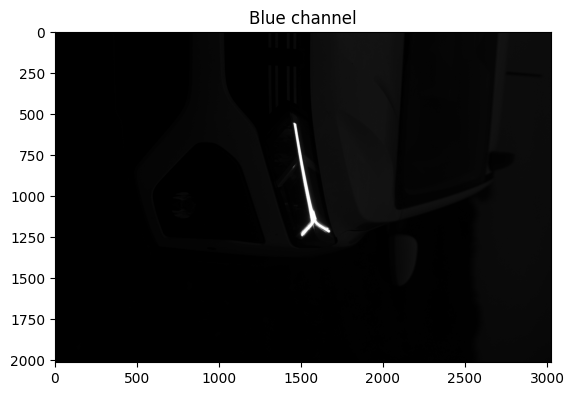

In [16]:
plt.imshow(r, cmap="gray")
plt.title("Red channel")
plt.show()

plt.imshow(b, cmap="gray")
plt.title("Blue channel")
plt.show()

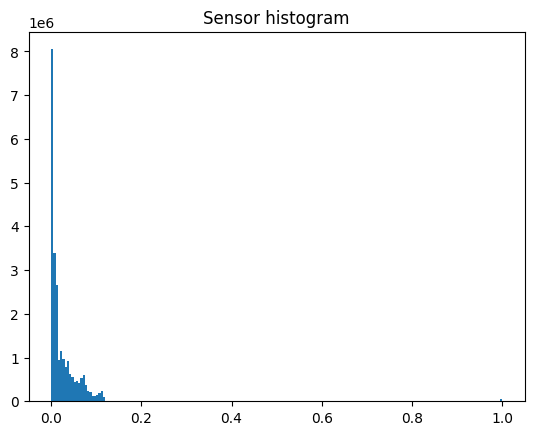

In [17]:
plt.hist(sensor.flatten(), bins=200)
plt.title("Sensor histogram")
plt.show()

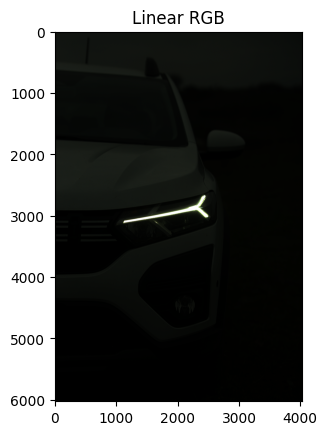

In [18]:
rgb_linear = raw.postprocess(
    gamma=(1,1),
    no_auto_bright=True,
    output_bps=16
)

plt.imshow(rgb_linear / 65535)
plt.title("Linear RGB")
plt.show()

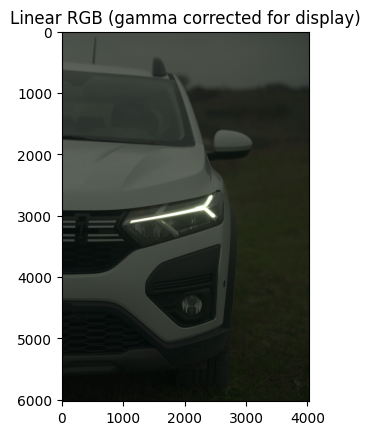

In [19]:
img = rgb_linear.astype(np.float32) / 65535

gamma = 1/2.2
img_display = np.power(img, gamma)

plt.imshow(img_display)
plt.title("Linear RGB (gamma corrected for display)")
plt.show()